In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("data/Japan_Visitor_Data.csv")

In [91]:
df.index.name = 't'
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Year,Month,Days,Date,Total_Visitors,Daily_Visitors,%Change,Notes
t,,,,,,,,
0,1996,Jan,31,1996-01-01,276086,8906.000000,NaN,NaN
1,1996,Feb,29,1996-02-01,283667,9781.620690,NaN,NaN
2,1996,Mar,31,1996-03-01,310702,10022.645161,NaN,NaN
3,1996,Apr,30,1996-04-01,329303,10976.766667,NaN,NaN
4,1996,May,31,1996-05-01,326156,10521.161290,NaN,NaN


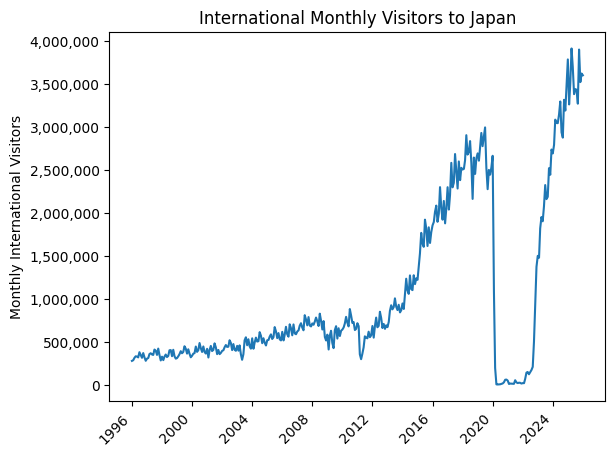

In [92]:
import matplotlib.ticker as mticker

ax = sns.lineplot(data=df, x="Date", y="Total_Visitors")

ax.set(
    xlabel = "",
    ylabel="Monthly International Visitors",
    title="International Monthly Visitors to Japan"
)

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45, ha="right");

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_64582/2575864605.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  yearly_tourists = df.groupby("Year").sum()


      Days  Total_Visitors  Daily_Visitors     %Change
Year                                                  
2022   365         3832110    1.251809e+05  238.740000
2023   365        25066350    8.229904e+05  281.103343
2024   366        36870148    1.208727e+06    6.049149
2025   365        42683746    1.403289e+06    1.951869
2026    31         3597500    1.160484e+05   -0.048690


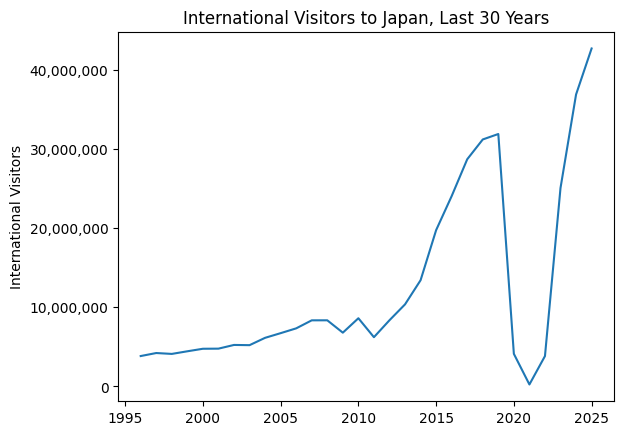

In [93]:
# Plotting Yearly Visitors
yearly_tourists = df.groupby("Year").sum()
print(yearly_tourists.tail())
ax = sns.lineplot(data = yearly_tourists[0:-1], x= "Year", y = "Total_Visitors")
ax.ticklabel_format(style='plain', axis='y')

ax.set(
    xlabel="",
    ylabel="International Visitors",
    title="International Visitors to Japan, Last 30 Years"
)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

In [94]:
# Reformatting the table so I can seperate the trends by year
df_pivot = df.pivot(index = "Year", columns = "Month", values = "Total_Visitors")
new_order = ['Jan', 'Feb', 'Mar', "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
table3 = df_pivot.reindex(new_order, axis=1)
table4 = table3.T
table4

Year,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
Month,,,,,,,,,,,,,,,,,,,,,
Jan,276086.0,302148.0,324913.0,308764.0,335621.0,416490.0,392588.0,450847.0,538334.0,516280.0,...,2295668.0,2501409.0,2689339.0,2661022.0,46522.0,17766.0,1497472.0,2688478.0,3781629.0,3597500.0
Feb,283667.0,309318.0,284792.0,330460.0,360621.0,315483.0,400081.0,394869.0,417519.0,519460.0,...,2035771.0,2509297.0,2604322.0,1085147.0,7355.0,16719.0,1475455.0,2788224.0,3258491.0,NaN
Mar,310702.0,355228.0,325185.0,353512.0,365689.0,401054.0,434034.0,456614.0,488778.0,557640.0,...,2205664.0,2607956.0,2760136.0,193658.0,12276.0,66121.0,1817616.0,3081781.0,3497755.0,NaN
Apr,329303.0,364875.0,349854.0,388777.0,443028.0,449934.0,460377.0,354054.0,546662.0,584406.0,...,2578970.0,2900718.0,2926685.0,2917.0,10853.0,139548.0,1949236.0,3043003.0,3909128.0,NaN
May,326156.0,350961.0,320277.0,364474.0,381053.0,390515.0,438537.0,288562.0,500830.0,530752.0,...,2294717.0,2675052.0,2773091.0,1663.0,10035.0,147046.0,1899176.0,3040294.0,3693587.0,NaN
Jun,316699.0,345070.0,333460.0,379914.0,400139.0,403477.0,441123.0,352431.0,505003.0,551134.0,...,2346442.0,2704631.0,2880041.0,2565.0,9251.0,120430.0,2073441.0,3140642.0,3377985.0,NaN
Jul,377070.0,407510.0,399305.0,446236.0,483849.0,479822.0,516013.0,515692.0,610190.0,669172.0,...,2681518.0,2832040.0,2991189.0,3782.0,51055.0,144578.0,2320694.0,3292602.0,3437118.0,NaN
Aug,345020.0,395056.0,401594.0,418094.0,423361.0,433490.0,484771.0,550380.0,567869.0,618655.0,...,2477428.0,2578021.0,2520134.0,8658.0,25916.0,169902.0,2157190.0,2933381.0,3428406.0,NaN
Sep,311881.0,345382.0,330401.0,360579.0,379753.0,354578.0,401407.0,457574.0,481570.0,540462.0,...,2280406.0,2159595.0,2272883.0,13684.0,17720.0,206641.0,2184442.0,2872487.0,3267228.0,NaN


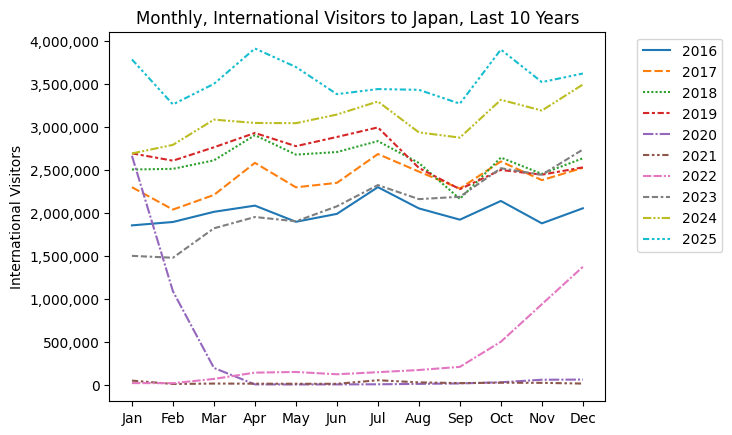

In [95]:
ax = sns.lineplot(data = table4.iloc[:, -11:-1])
ax.ticklabel_format(style='plain', axis='y')

ax.set(
    xlabel="",
    ylabel="International Visitors",
    title="Monthly, International Visitors to Japan, Last 10 Years"
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

Because we care about "crowdedness", it would actually be easier to put the data in terms of visitors per day per month rather than simply visitors per month. This is because each month doesn't contain the same number of days. For example, February has 90.3% as many days as January (on non-leap years), which would make February appear to be less crowded. We previously calculated the number of daily visitors in the ETL process.

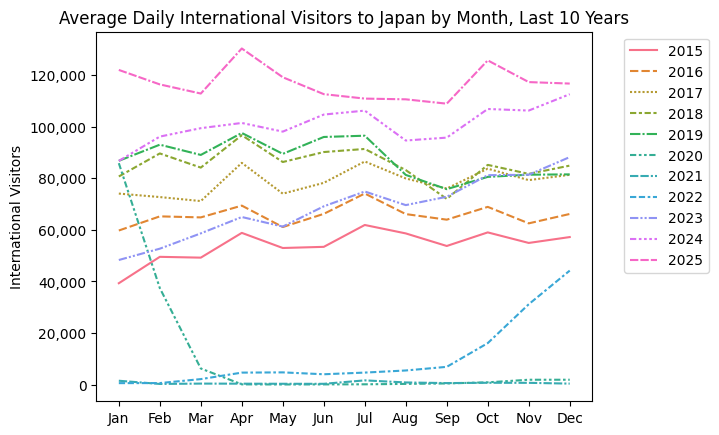

In [96]:
df_daily_pivot = df.pivot(index = "Year", columns = "Month", values = "Daily_Visitors")
new_order = ['Jan', 'Feb', 'Mar', "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
table3 = df_daily_pivot.reindex(new_order, axis=1)
table4 = table3.T

ax = sns.lineplot(data = table4.iloc[:, -12:-1])
ax.ticklabel_format(style='plain', axis='y')


ax.set(
    xlabel="",
    ylabel="International Visitors",
    title="Average Daily International Visitors to Japan by Month, Last 10 Years"
)
current_values = plt.gca().get_yticks()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

That's better. Let's now perform classical decomposition. Since the cyclic variation seems to scale as the total number of visitors increases, it would be best if we did multiplicative decomposition. 

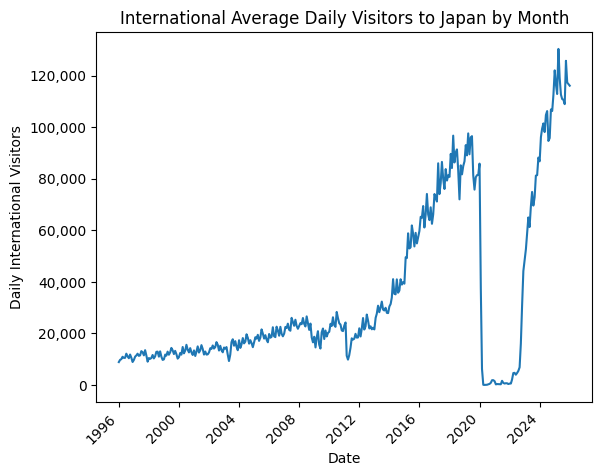

In [97]:
ax = sns.lineplot(data = df, x= "Date", y = "Daily_Visitors")

ax.set(
    ylabel="Daily International Visitors",
    title="International Average Daily Visitors to Japan by Month"
)

current_values = plt.gca().get_yticks()
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45, ha="right");

Let's get a rolling average on a 2 x 12 cycle (every 12 months). We can use the pandas 'rolling' function.

In [98]:

rolling_2 = df[["Daily_Visitors"]].rolling(12, center=True).mean()
rolling_2.iloc[0:12,]
rolling_2.index = rolling_2.index - 1
rolling_2.iloc[0:12,]
rolling_3 = rolling_2.rolling(2).mean()
rolling_3.iloc[0:12,]
rolling_3.columns = ["Daily_Arrivals_Moving_Avg"]

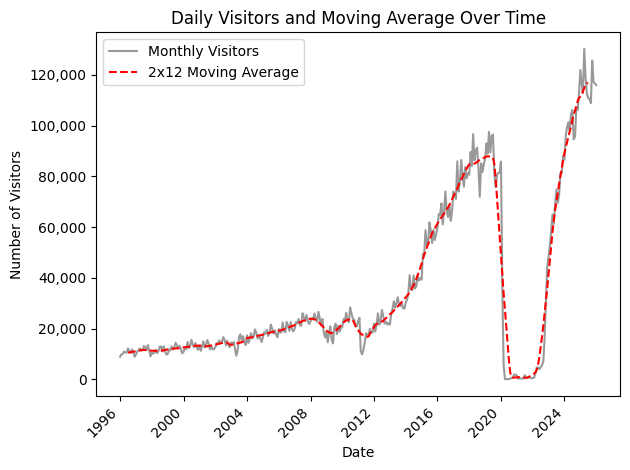

In [99]:
daily_avg = pd.merge(df, rolling_3, on = "t", how = "left")
fig, ax = plt.subplots()

sns.lineplot(
    data=daily_avg, x="Date", y="Daily_Visitors",
    alpha=0.8, color="Gray", label="Monthly Visitors",
    ax=ax
)

sns.lineplot(
    data=daily_avg, x="Date", y="Daily_Arrivals_Moving_Avg",
    alpha=1, color="Red", linestyle="--",
    label="2x12 Moving Average",
    ax=ax
)

ax.set_title("Daily Visitors and Moving Average Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Visitors")

ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45, ha="right")

ax.legend()
plt.tight_layout()

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_64582/1815776444.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_avg_cut.loc[: ,"detrended"] = daily_avg_cut.loc[:,"Daily_Visitors"]/daily_avg_cut.loc[:,"Daily_Arrivals_Moving_Avg"]


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

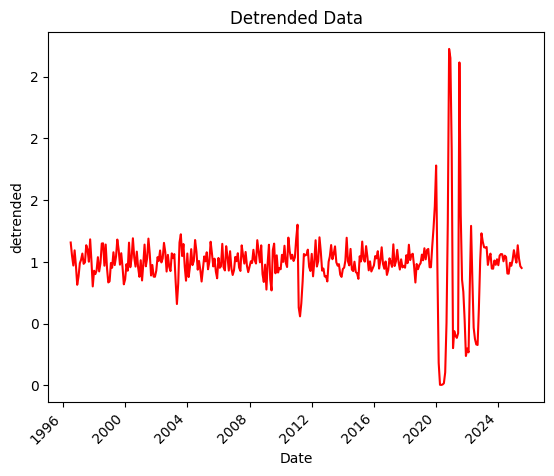

In [100]:
# We can divide the overall line to get the detrended average

daily_avg_cut = daily_avg[6:-6]
daily_avg_cut.loc[: ,"detrended"] = daily_avg_cut.loc[:,"Daily_Visitors"]/daily_avg_cut.loc[:,"Daily_Arrivals_Moving_Avg"]

ax = sns.lineplot(data = daily_avg_cut, x = "Date", y = "detrended", 
             alpha = 1, 
             color = "Red")
ax.set_title("Detrended Data")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45, ha="right")

In [101]:
# Adjusting them so they add to 12
daily_avg_cut["Month_num"] = daily_avg_cut["Date"].dt.month
sum_monthly_trends = daily_avg_cut.groupby("Month_num")["detrended"].mean().sum()

multiplier = 12/sum_monthly_trends
normalized_sum_monthly_trends = multiplier * daily_avg_cut.groupby("Month_num")[["detrended"]].mean()
normalized_sum_monthly_trends.sum()
normalized_sum_monthly_trends


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_64582/2536329981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_avg_cut["Month_num"] = daily_avg_cut["Date"].dt.month


,detrended
Month_num,
1,1.033749
2,0.967949
3,0.949933
4,1.050110
5,0.913717
6,0.931723
7,1.135749
8,1.020808
9,0.930796


In [102]:
# close enough to 12
seasonal_df = pd.merge(daily_avg_cut, normalized_sum_monthly_trends, on = "Month_num", how = "left")

In [103]:
seasonal_df = seasonal_df.rename(columns = {'detrended_y':'seasonal_component'})
# run below if you need
#seasonal_df.drop(columns = "detrended_x", inplace= True)
seasonal_df

,Year,Month,Days,Date,Total_Visitors,Daily_Visitors,%Change,Notes,Daily_Arrivals_Moving_Avg,detrended_x,Month_num,seasonal_component
0,1996,Jul,31,1996-07-01,377070,12163.548387,NaN,NaN,10516.635416,1.156601,7,1.135749
1,1996,Aug,31,1996-08-01,345020,11129.677419,NaN,NaN,10604.392100,1.049535,8,1.020808
2,1996,Sep,30,1996-09-01,311881,10396.033333,NaN,NaN,10716.965988,0.970054,9,0.930796
3,1996,Oct,31,1996-10-01,366841,11833.580645,NaN,NaN,10826.218318,1.093048,10,1.055342
4,1996,Nov,30,1996-11-01,316551,10551.700000,NaN,NaN,10908.963927,0.967250,11,1.020959
...,...,...,...,...,...,...,...,...,...,...,...,...
344,2025,Mar,31,2025-03-01,3497755,112830.806452,0.134928,Preliminary,113558.623797,0.993591,3,0.949933
345,2025,Apr,30,2025-04-01,3909128,130304.266667,0.284553,Preliminary,114892.266315,1.134143,4,1.050110
346,2025,May,31,2025-05-01,3693587,119147.967742,0.214878,Preliminary,116137.407444,1.025922,5,0.913717
347,2025,Jun,30,2025-06-01,3377985,112599.500000,0.075571,Preliminary,116768.947766,0.964293,6,0.931723


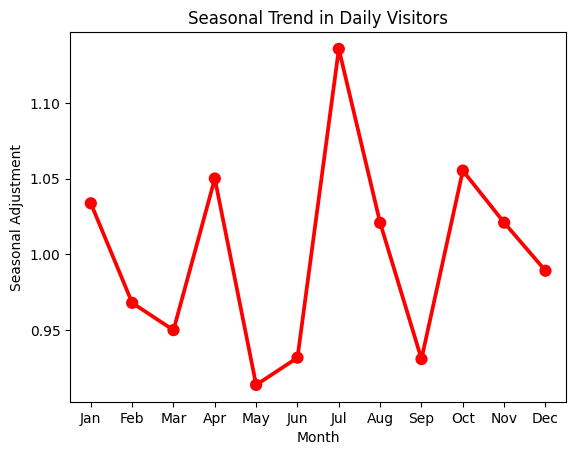

In [104]:
ax = sns.pointplot(data = seasonal_df[6:18], x = 'Month', y = "seasonal_component", 
             color = "Red")

ax.set_title("Seasonal Trend in Daily Visitors")
ax.set_xlabel("Month")
ax.set_ylabel("Seasonal Adjustment")
plt.show()

Acording to classical decomposition, May is the least crowded month for tourism while july is the most crowded month for tourism

July is 25.6% more crowded than May on average.

This is all well and good, but the pandemic may have obfuscated predictible seasonal trends through the randomness of arbitrary Japanese travel decisions. Let's re-run the analysis with the COVID years (2020-2022) removed.

In [105]:
# Getting the reminded component
seasonal_df["remainder"] = seasonal_df.loc[:,"Daily_Visitors"]/(seasonal_df.loc[:,"seasonal_component"]*seasonal_df.loc[:,"Daily_Arrivals_Moving_Avg"])
seasonal_df

,Year,Month,Days,Date,Total_Visitors,Daily_Visitors,%Change,Notes,Daily_Arrivals_Moving_Avg,detrended_x,Month_num,seasonal_component,remainder
0,1996,Jul,31,1996-07-01,377070,12163.548387,NaN,NaN,10516.635416,1.156601,7,1.135749,1.018359
1,1996,Aug,31,1996-08-01,345020,11129.677419,NaN,NaN,10604.392100,1.049535,8,1.020808,1.028141
2,1996,Sep,30,1996-09-01,311881,10396.033333,NaN,NaN,10716.965988,0.970054,9,0.930796,1.042176
3,1996,Oct,31,1996-10-01,366841,11833.580645,NaN,NaN,10826.218318,1.093048,10,1.055342,1.035729
4,1996,Nov,30,1996-11-01,316551,10551.700000,NaN,NaN,10908.963927,0.967250,11,1.020959,0.947394
...,...,...,...,...,...,...,...,...,...,...,...,...,...
344,2025,Mar,31,2025-03-01,3497755,112830.806452,0.134928,Preliminary,113558.623797,0.993591,3,0.949933,1.045959
345,2025,Apr,30,2025-04-01,3909128,130304.266667,0.284553,Preliminary,114892.266315,1.134143,4,1.050110,1.080023
346,2025,May,31,2025-05-01,3693587,119147.967742,0.214878,Preliminary,116137.407444,1.025922,5,0.913717,1.122801
347,2025,Jun,30,2025-06-01,3377985,112599.500000,0.075571,Preliminary,116768.947766,0.964293,6,0.931723,1.034957


In [106]:
seasonal_df.to_csv("Data/cleaned_df.csv")